In [1]:
# Install compatible versions as per Appendix 6.1
!pip install numpy==1.23.5
!pip install gensim
!pip install jax==0.4.13

# Restart runtime after running this cell

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 21.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 9.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for jax: filename=jax-0.4.13-py3-none-any.whl size=1

In [2]:
# Install compatible versions for Python 3.12 environment
!pip install numpy==1.26.4
!pip install gensim
!pip install jax==0.4.26  # Updated JAX for Python 3.12 compatibility

# IMPORTANT: After running this, go to 'Runtime' -> 'Restart Session'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 60.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
optax 0.2.8 requires jax>=0.5.3, but you have jax 0.4.13 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 13.0 MB/s eta 0:00:00
  Attempting uninstall: jax
    Found existing installation: jax 0.4.13
    Uninstalling jax-0.4.13:
      Successfully uninstalled jax-0.4.13
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
optax 0.2.8 requires jax>=0.5.3, but you have jax 0.4.26 which is incompatible.
orbax-checkpoint 0.11.36 requires jax>=0.6.0, but you have jax 0.4.26 which is incompatible.
flax 0.11.2 requires jax>=0.6.0, but you have jax 0.4.26 which is incompatible.


In [1]:
from google.colab import files
uploaded = files.upload()

Saving Hotel_Reviews.csv to Hotel_Reviews.csv


In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.9 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning Imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# NLP Specific
import gensim.downloader as api

print("All modules loaded successfully!")

All modules loaded successfully!


In [5]:
# 1. Load the dataset
df = pd.read_csv('Hotel_Reviews.csv')

# 2. Convert Ratings into Binary Labels (0 = Positive, 1 = Negative)
# Note: Rating 4-5 are Positive, 1-3 are Negative
df['label'] = df['Rating'].apply(lambda x: 0 if x >= 4 else 1)

# 3. Clean the text (Removing special characters and lowercasing)
nltk.download('stopwords')
nltk.download('wordnet')

def clean_review(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    return text

df['cleaned_review'] = df['Review'].apply(clean_review)

# 4. Split data (80% Training, 20% Testing)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['cleaned_review'], df['label'], test_size=0.2, random_state=42
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [14]:
# 1. Initialize Tokenizer
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train_raw)

# 2. Convert text to sequences
train_sequences = tokenizer.texts_to_sequences(X_train_raw)
test_sequences = tokenizer.texts_to_sequences(X_test_raw)

# 3. Padding (Making all reviews the same length)
max_len = 100
X_train = pad_sequences(train_sequences, maxlen=max_len, padding='post')
X_test = pad_sequences(test_sequences, maxlen=max_len, padding='post')

vocab_size = len(tokenizer.word_index) + 1

In [7]:
# 1. Initialize Tokenizer
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train_raw)

# 2. Convert text to sequences
train_sequences = tokenizer.texts_to_sequences(X_train_raw)
test_sequences = tokenizer.texts_to_sequences(X_test_raw)

# 3. Padding (Making all reviews the same length)
max_len = 100
X_train = pad_sequences(train_sequences, maxlen=max_len, padding='post')
X_test = pad_sequences(test_sequences, maxlen=max_len, padding='post')

vocab_size = len(tokenizer.word_index) + 1

In [8]:
# --- MODEL 1: Simple RNN ---
model1 = Sequential([
    Embedding(vocab_size, 32, input_length=max_len),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Training Model 1...")
history1 = model1.fit(X_train, y_train, epochs=3, validation_split=0.1, batch_size=64)

# --- MODEL 2: LSTM ---
model2 = Sequential([
    Embedding(vocab_size, 32, input_length=max_len),
    LSTM(32),
    Dense(1, activation='sigmoid')
])
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Training Model 2...")
history2 = model2.fit(X_train, y_train, epochs=3, validation_split=0.1, batch_size=64)

Training Model 1...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


231/231 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.7324 - loss: 0.5740 - val_accuracy: 0.7585 - val_loss: 0.5404
Epoch 2/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.7734 - loss: 0.5144 - val_accuracy: 0.8073 - val_loss: 0.4915
Epoch 3/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.8427 - loss: 0.3972 - val_accuracy: 0.8024 - val_loss: 0.4952
Training Model 2...
Epoch 1/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.7655 - loss: 0.5325 - val_accuracy: 0.8238 - val_loss: 0.4661
Epoch 2/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.8174 - loss: 0.4721 - val_accuracy: 0.7878 - val_loss: 0.5166
Epoch 3/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.8355 - loss: 0.4446 - val_accuracy: 0.8506 - val_loss: 0.4169


In [9]:
# 1. Load Pre-trained Vectors
print("Downloading Word2Vec vectors...")
w2v = api.load('glove-wiki-gigaword-50')

# 2. Build the Weight Matrix
embedding_matrix = np.zeros((vocab_size, 50))
for word, i in tokenizer.word_index.items():
    if word in w2v:
        embedding_matrix[i] = w2v[word]

# 3. Model with Pre-trained Weights
model3 = Sequential([
    Embedding(vocab_size, 50, weights=[embedding_matrix],
              input_length=max_len, trainable=False),
    LSTM(64),
    Dense(1, activation='sigmoid')
])
model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Training Model 3...")
history3 = model3.fit(X_train, y_train, epochs=3, validation_split=0.1, batch_size=64)

[==================================================] 100.0% 66.0/66.0MB downloaded
Training Model 3...
Epoch 1/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - accuracy: 0.7617 - loss: 0.5048 - val_accuracy: 0.6616 - val_loss: 0.5139
Epoch 2/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.7441 - loss: 0.5478 - val_accuracy: 0.7494 - val_loss: 0.5530
Epoch 3/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.7345 - loss: 0.5652 - val_accuracy: 0.7506 - val_loss: 0.5529


In [10]:
def get_metrics(model, name):
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))

get_metrics(model1, "Simple RNN")
get_metrics(model2, "LSTM")
get_metrics(model3, "Word2Vec LSTM")

129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step

--- Simple RNN Classification Report ---
              precision    recall  f1-score   support

           0       0.81      0.92      0.86      3042
           1       0.63      0.39      0.48      1057

    accuracy                           0.78      4099
   macro avg       0.72      0.65      0.67      4099
weighted avg       0.77      0.78      0.76      4099

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step

--- LSTM Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      3042
           1       0.74      0.62      0.68      1057

    accuracy                           0.85      4099
   macro avg       0.81      0.77      0.79      4099
weighted avg       0.84      0.85      0.84      4099

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

--- Word2Vec LSTM Classification Report ---
              precision    recall  f1-score   support

           0       0.74      1.00      0.8

In [11]:
# --- MODEL 1: Simple RNN ---
model1 = Sequential([
    Embedding(vocab_size, 32, input_length=max_len),
    SimpleRNN(32, dropout=0.2),
    Dense(1, activation='sigmoid')
])
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Training Model 1 (Simple RNN)...")
history1 = model1.fit(X_train, y_train, epochs=3, validation_split=0.1, batch_size=64)

# --- MODEL 2: Standard LSTM ---
model2 = Sequential([
    Embedding(vocab_size, 32, input_length=max_len),
    LSTM(32, dropout=0.2),
    Dense(1, activation='sigmoid')
])
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\nTraining Model 2 (Standard LSTM)...")
history2 = model2.fit(X_train, y_train, epochs=3, validation_split=0.1, batch_size=64)

Training Model 1 (Simple RNN)...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


231/231 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.7277 - loss: 0.5807 - val_accuracy: 0.7488 - val_loss: 0.5563
Epoch 2/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.7586 - loss: 0.5198 - val_accuracy: 0.7366 - val_loss: 0.5662
Epoch 3/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.8133 - loss: 0.4558 - val_accuracy: 0.7713 - val_loss: 0.5223

Training Model 2 (Standard LSTM)...
Epoch 1/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.7482 - loss: 0.5592 - val_accuracy: 0.8287 - val_loss: 0.4582
Epoch 2/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - accuracy: 0.7945 - loss: 0.4763 - val_accuracy: 0.7927 - val_loss: 0.4545
Epoch 3/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.8345 - loss: 0.4320 - val_accuracy: 0.7915 - val_loss: 0.4711


In [12]:
# --- MODEL 3: LSTM with Word2Vec ---
model3 = Sequential([
    Embedding(vocab_size, 50, weights=[embedding_matrix],
              input_length=max_len, trainable=False),
    LSTM(64, dropout=0.2),
    Dense(1, activation='sigmoid')
])
model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\nTraining Model 3 (Word2Vec LSTM)...")
history3 = model3.fit(X_train, y_train, epochs=3, validation_split=0.1, batch_size=64)


Training Model 3 (Word2Vec LSTM)...
Epoch 1/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - accuracy: 0.7419 - loss: 0.5507 - val_accuracy: 0.7799 - val_loss: 0.5214
Epoch 2/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - accuracy: 0.7326 - loss: 0.5363 - val_accuracy: 0.7494 - val_loss: 0.5166
Epoch 3/3
231/231 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.7342 - loss: 0.5398 - val_accuracy: 0.7500 - val_loss: 0.5267


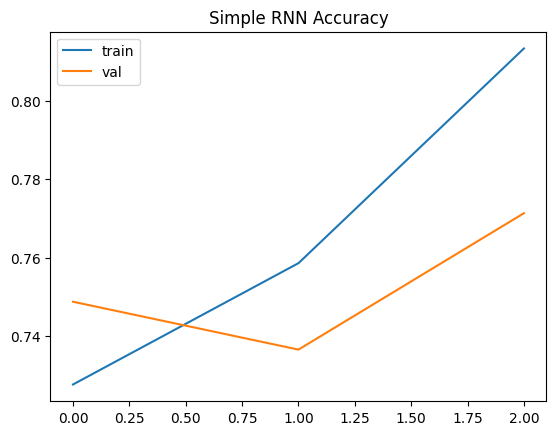

129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step

--- Simple RNN Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.94      0.86      3042
           1       0.63      0.29      0.40      1057

    accuracy                           0.77      4099
   macro avg       0.71      0.62      0.63      4099
weighted avg       0.75      0.77      0.74      4099



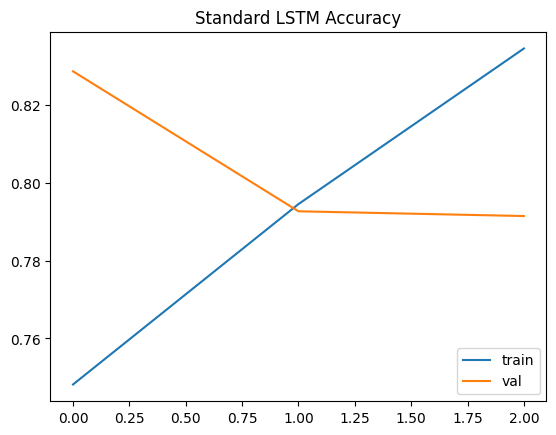

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step

--- Standard LSTM Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      3042
           1       0.61      0.65      0.63      1057

    accuracy                           0.80      4099
   macro avg       0.75      0.75      0.75      4099
weighted avg       0.81      0.80      0.81      4099



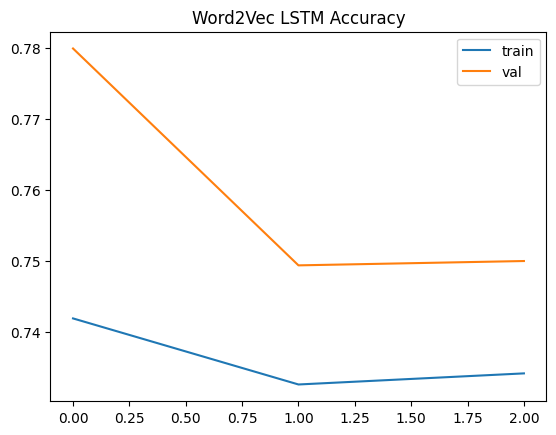

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step

--- Word2Vec LSTM Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.99      0.85      3042
           1       0.70      0.05      0.09      1057

    accuracy                           0.75      4099
   macro avg       0.72      0.52      0.47      4099
weighted avg       0.74      0.75      0.66      4099



In [13]:
def plot_and_report(model, history, name):
    # Plot Accuracy
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(f'{name} Accuracy')
    plt.legend()
    plt.show()

    # Classification Report
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))

# Generate reports for all three
plot_and_report(model1, history1, "Simple RNN")
plot_and_report(model2, history2, "Standard LSTM")
plot_and_report(model3, history3, "Word2Vec LSTM")